# 19 — a real measurement

Every fit in this series so far has been to data the model itself produced. That
is how you find out what a method can do and it settles nothing about what it
does on a spectrometer. This notebook reads the first real measurement:
**CBM56 variant 3**, measured by Alex on a Paris setup, sent by Suren at Claus's
request, and living in `data/CBM56/Var3_TAC`.

No fitting here. This notebook is about knowing what the files contain before
anything is fitted to them — where the pulses are, what the instrument response
looks like in each detector, how much background there is, and whether the
calibration file and the data agree.

**The geometry is one this series already describes.** Three samples, two
interleaved pulses, four detectors: that is `experiment.mfd_pie()` from notebook
11. Pointing the description at this measurement is filling in numbers.


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import cbm56
import experiment as X


## The calibration file

`Paris_x64 info.txt` is Paris's own record of how the measurement was set up and
how Alex fitted it. It is the only place several of these numbers appear.


In [2]:
d = cbm56.load()
c = d['cal']
print(f'TAC calibration      {c["dt"] * 1000:.0f} ps over {c["n_channels"]} channels '
      f'= {c["tac_range"]:.3f} ns')
print(f'laser period         {c["period"]:.5f} ns  ({c["period"] / c["dt"]:.2f} channels)')
print(f'g factor             green {c["g_green"]:.4f}   red {c["g_red"]:.4f}')
print(f'polarisation mixing  l1 {c["l1"]:.4f}   l2 {c["l2"]:.4f}')
print(f'scatter count rates  green {c["scatter_green_hz"]:.0f} Hz   '
      f'red {c["scatter_red_hz"]:.0f} Hz   "yellow" {c["scatter_yellow_hz"]:.0f} Hz')
print(f'fit windows          green {c["window_green"]}   sensitised {c["window_red"]}   '
      f'red pulse {c["window_yellow"]}')
print()
print("Alex's own single-molecule constants, for comparison later:")
print(f'  donor lifetime {c["tau_donor"]:.1f} ns, DA lifetime {c["tau_da"]:.1f} ns, '
      f'crosstalk {c["crosstalk"]:.3f}, direct excitation {c["direct_excitation"]:.3f}, '
      f'quantum yields {c["qy_donor"]:.2f} and {c["qy_acceptor"]:.2f}')


TAC calibration      64 ps over 512 channels = 32.768 ns
laser period         31.24923 ns  (488.27 channels)
g factor             green 1.0720   red 1.1056
polarisation mixing  l1 0.0175   l2 0.0526
scatter count rates  green 471 Hz   red 188 Hz   "yellow" 145 Hz
fit windows          green (13, 250)   sensitised (40, 250)   red pulse (258, 425)

Alex's own single-molecule constants, for comparison later:
  donor lifetime 4.0 ns, DA lifetime 2.0 ns, crosstalk 0.070, direct excitation 0.010, quantum yields 0.70 and 0.30


The three "colours" are Paris's names for three **windows**, not three detectors.
Green is the donor emission after the green pulse; red is the *acceptor* emission
after the green pulse, which is the sensitised signal; and yellow is the acceptor
after its own pulse. The last two are the same two detectors, read in two
different parts of the period — which is what pulsed interleaved excitation is.

## The files

Fourteen files, each **1024 numbers: two 512-channel histograms**, the parallel
and perpendicular halves of one detector pair. The pair is in the file name:
`10ps` is green (Paris channels 1 and 0), `32ps` is red (channels 3 and 2).


In [3]:
print(f'{len(d["sample"])} sample histograms, {len(d["irf"])} water, {len(d["reference"])} reference dye')
print()
print(f'{"burst cut":<12}{"seconds":>9}{"green":>12}{"red":>12}   photons')
for s in ('D0', 'A0', 'DA'):
    g = sum(d['sample'][(s, 'green', p)].sum() for p in cbm56.POLARISATIONS)
    r = sum(d['sample'][(s, 'red', p)].sum() for p in cbm56.POLARISATIONS)
    print(f'{s + " (" + cbm56.SAMPLES[s] + ")":<12}{d["seconds"][s]:>9.1f}{g:>12,.0f}{r:>12,.0f}')


12 sample histograms, 8 water, 8 reference dye

burst cut     seconds       green         red   photons
D0 (donor only)     26.0     664,744      48,010
A0 (acceptor only)     27.5      39,893     413,486
DA (both, the FRET sample)     71.3     907,724   1,019,520


## The measurement, described

Nothing about the geometry is written out here. `cbm56.experiment()` takes the
description `experiment.py` already has — three samples, two interleaved pulses,
four detectors — and fills in this spectrometer's detector names and pulse
separation from the calibration file.


In [4]:
exp = cbm56.experiment()
print(exp.summary())


CBM56 Var3, Paris, 32 MHz PIE: 24 histograms
  samples     D0 (donor), A0 (acceptor), DA (donor+acceptor)
  excitations green at 0 ns, reaches donor x 1.0, acceptor x EX_AG, red at 15.68 ns, reaches acceptor x 1.0, donor x EX_DR
  detectors   gp (green), gs (green), rp (red), rs (red)
  histograms
    D0  gp_vv    parallel      donor
    D0  g2p_vv   parallel      donor (EX_DR)
    D0  gs_vh    perpendicular donor
    D0  g2s_vh   perpendicular donor (EX_DR)
    D0  rp_vv    parallel      donor
    D0  r2p_vv   parallel      donor (EX_DR)
    D0  rs_vh    perpendicular donor
    D0  r2s_vh   perpendicular donor (EX_DR)
    A0  gp_vv    parallel      acceptor directly (EX_AG)
    A0  g2p_vv   parallel      acceptor directly
    A0  gs_vh    perpendicular acceptor directly (EX_AG)
    A0  g2s_vh   perpendicular acceptor directly
    A0  rp_vv    parallel      acceptor directly (EX_AG)
    A0  r2p_vv   parallel      acceptor directly
    A0  rs_vh    perpendicular acceptor directly (EX_AG

In [5]:
text = exp.to_json('cbm56_var3.json')
assert X.Experiment.from_json(text).to_dict() == exp.to_dict()
print(f'written to cbm56_var3.json and read back identically '
      f'({len(exp.channels)} physics channels in {len(d["sample"])} histograms)')


written to cbm56_var3.json and read back identically (24 physics channels in 12 histograms)


## The histograms

Twelve, on a log scale, with the two pulses marked. The green pulse is near
channel 20 and the red near 265, so **one histogram holds both windows** — which
is the route this series already fits, each labelled histogram carrying both
pulses in its mean.


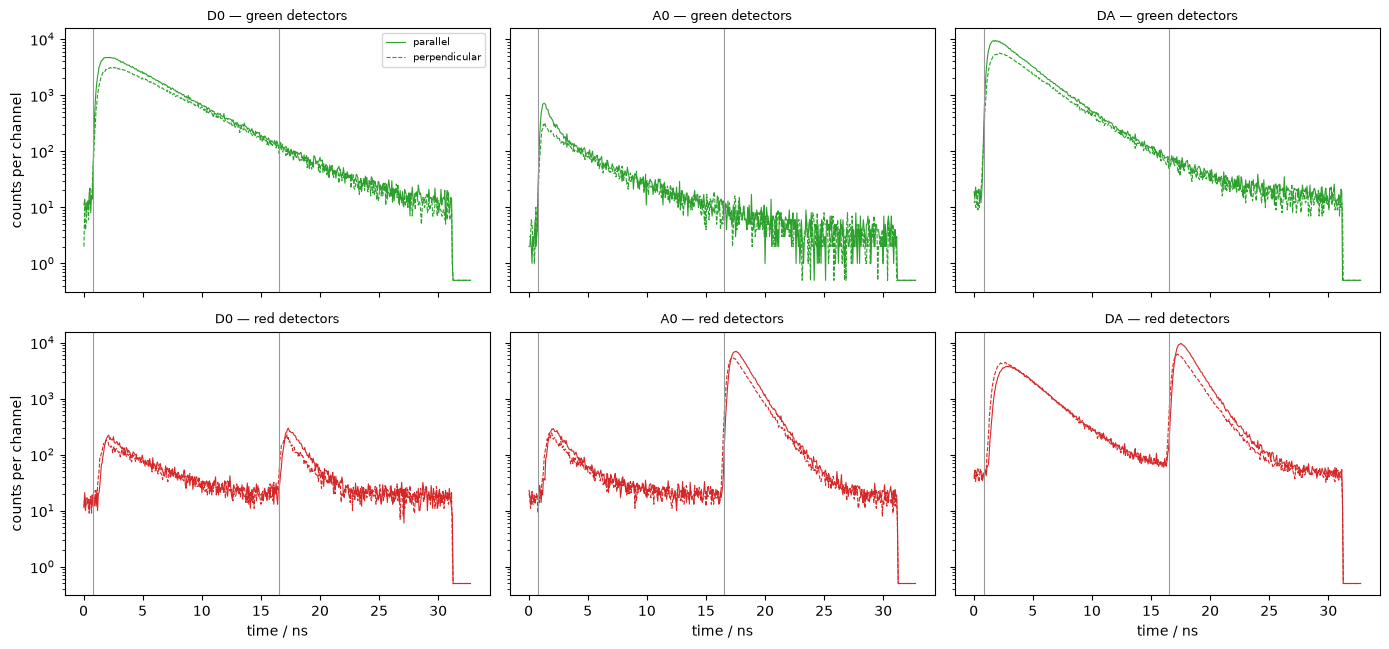

In [6]:
t = d['t']
fig, axes = plt.subplots(2, 3, figsize=(14, 6.6), sharex=True, sharey='row')
for j, s in enumerate(('D0', 'A0', 'DA')):
    for i, colour in enumerate(('green', 'red')):
        ax = axes[i, j]
        for pol, style in zip(cbm56.POLARISATIONS, ('-', '--')):
            h = d['sample'][(s, colour, pol)]
            ax.semilogy(t, np.maximum(h, 0.5), style, lw=0.8,
                        color='C2' if colour == 'green' else 'C3', label=pol)
        ax.axvline(c['window_green'][0] * c['dt'], color='0.6', lw=0.8)
        ax.axvline(c['window_yellow'][0] * c['dt'], color='0.6', lw=0.8)
        ax.set_title(f'{s} — {colour} detectors', fontsize=9)
        if i == 1:
            ax.set_xlabel('time / ns')
        if j == 0:
            ax.set_ylabel('counts per channel')
        if i == 0 and j == 0:
            ax.legend(fontsize=7)
fig.tight_layout(); plt.show()


Read the six panels against what each sample is.

* **D0 green** is the donor's own decay — the biggest histogram in the folder
  and the one the donor lifetime comes from.
* **D0 red** is almost empty: a donor-only sample has nothing to emit in the red,
  so what is there is crosstalk and background.
* **A0 red** is nearly all in the second window, because the acceptor is excited
  by its own pulse; the small part in the first window is the green laser
  exciting the acceptor directly, which is the quantity `EX_AG` in the model.
* **DA red** has both: sensitised emission in the first window, direct excitation
  in the second, and they are comparable.

## The instrument response

Two water measurements, both detector pairs. The question that matters is
whether the **red detectors see the green pulse** — the sensitised-emission
window needs a response of its own, and if water does not provide one it has to
come from somewhere else.


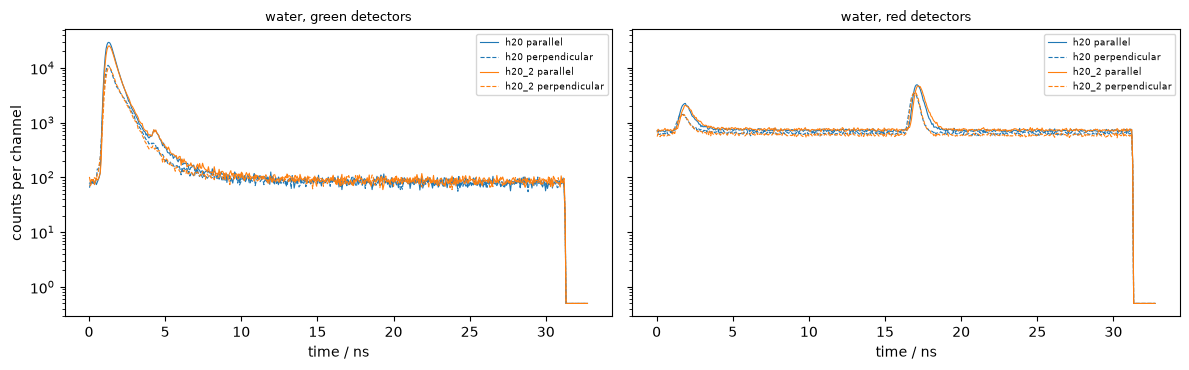

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, colour in zip(axes, ('green', 'red')):
    for which, col in zip(('h20', 'h20_2'), ('C0', 'C1')):
        for pol, style in zip(cbm56.POLARISATIONS, ('-', '--')):
            h = d['irf'][(which, colour, pol)]
            ax.semilogy(t, np.maximum(h, 0.5), style, lw=0.8, color=col,
                        label=f'{which} {pol}')
    ax.set_title(f'water, {colour} detectors', fontsize=9)
    ax.set_xlabel('time / ns'); ax.legend(fontsize=6.5)
axes[0].set_ylabel('counts per channel')
fig.tight_layout(); plt.show()


In [8]:
pp = cbm56.pulse_positions(d)
print(f'{"":<22}{"green pulse":>22}{"red pulse":>22}')
print(f'{"":<22}{"channel":>10}{"photons":>12}{"channel":>10}{"photons":>12}')
for k, v in pp.items():
    name = f'{k[0]} {k[1]} {k[2][:4]}'
    print(f'{name:<22}{v["green_channel"]:>10d}{v["green_counts"]:>12,.0f}'
          f'{v["red_channel"]:>10d}{v["red_counts"]:>12,.0f}')


                                 green pulse             red pulse
                         channel     photons   channel     photons
h20 green para                20     411,528       302      19,110
h20 green perp                19     193,195       379      18,942
h20 red para                  29     205,619       267     215,086
h20 red perp                  26     175,746       264     178,475
h20_2 green para              20     373,858       341      20,399
h20_2 green perp              20     183,541       290      19,901
h20_2 red para                29     210,833       268     221,267
h20_2 red perp                26     165,637       264     169,747


Three things come out of that table.

**The red detectors do see the green pulse**, at about 205,000 photons against
215,000 for the red pulse. So the sensitised window has a measured response and
nothing has to be invented for it.

**The green detectors do not see the red pulse.** Their "red peak" lands on a
different channel in each of the four rows, which is what a peak-finder does to
noise. Physically right, and it means the counts the D0 sample shows in the
second window are not scattered laser light.

**The pulses do not arrive at the same channel in every detector.** The green
pulse peaks at channel 20 in the green detectors and 29 in the red ones — 0.58 ns
of colour shift — and the two polarisations of the red pair differ by three
channels. This is why the model carries a timing shift for every detector rather
than one for the instrument.

**And the two water measurements agree** to within a channel everywhere, which is
the check that they are both usable.

## The period, read off the data

The TAC range is 32.768 ns and the laser period is 31.249 ns, so the last two
dozen channels are outside the period. They are not a background estimate — they
are exactly zero, because the electronics never reach them. What they give
instead is an independent check of the period.


In [9]:
per = cbm56.period_from_data(d)
print(f'last channel carrying a count, across all {len(per["last_channel"])} histograms: '
      f'median {per["median"]:.0f}')
print(f'  that is {per["ns"]:.3f} ns')
print(f'  the calibration file says {per["stated"]:.5f} ns = {per["stated_channels"]:.2f} channels')
print(f'  they agree to {abs(per["stated_channels"] - per["median"]):.2f} of a channel')


last channel carrying a count, across all 28 histograms: median 488
  that is 31.232 ns
  the calibration file says 31.24923 ns = 488.27 channels
  they agree to 0.27 of a channel


## The background

With the end of the period empty by construction, the background has to come
from the flat parts of the decay. Two windows are used and quoted separately —
before the green pulse and at the end of the period — because they sit at
opposite ends and if they disagree the level is not flat and the number is not a
background.


In [10]:
print(f'{"histogram":<26}{"per channel":>13}{"before":>9}{"end":>9}{"of the histogram":>19}')
for s in ('D0', 'A0', 'DA'):
    for colour in ('green', 'red'):
        for pol in cbm56.POLARISATIONS:
            b = cbm56.background(d['sample'][(s, colour, pol)], c)
            print(f'{s + " " + colour + " " + pol[:4]:<26}'
                  f'{b["per_channel"]:>8.2f} +-{b["sd"]:<4.2f}'
                  f'{b["windows"][0]:>9.1f}{b["windows"][1]:>9.1f}'
                  f'{b["fraction_of_histogram"] * 100:>18.1f}%')


histogram                   per channel   before      end   of the histogram
D0 green para                15.06 +-0.73     15.1     15.0               2.0%
D0 green perp                11.22 +-0.89     13.7     10.4               2.0%
D0 red para                  17.57 +-0.71     14.8     18.5              34.7%
D0 red perp                  17.26 +-0.56     13.5     18.4              40.0%
A0 green para                 4.00 +-0.47      4.5      3.8               8.6%
A0 green perp                 3.43 +-0.37      5.2      2.9              10.8%
A0 red para                  19.41 +-0.53     17.5     20.0               4.3%
A0 red perp                  16.74 +-0.50     16.1     17.0               4.8%
DA green para                19.30 +-1.92     26.4     17.0               1.8%
DA green perp                15.69 +-1.89     24.6     12.9               2.2%
DA red para                  49.06 +-0.93     47.1     49.7               4.6%
DA red perp                  44.85 +-0.91     41.4    

**The donor-only sample's red histograms are 35 to 40 per cent background.**
That answers a question this notebook was written partly to ask: D0 shows counts
in the second window, where a sample with no acceptor should show none, and the
explanation is not an impure burst cut — it is that those histograms are weak
enough (48,000 photons against the FRET sample's 1,020,000) for background to be
more than a third of them.

**Two rows are not flat, and they are the two to be careful with.** D0 red reads
14.8 before the green pulse against 18.5 at the end of the period, and DA green
reads 26.4 against 17.0. In both the "background" is a background plus something
that is still decaying, so a single constant per histogram is an approximation
there. The model fits a background per histogram rather than taking these
numbers, and that is the right way round; what the table is for is knowing which
histograms will be sensitive to getting it wrong.

## What this establishes, and what is still needed

Established here: the data are twelve histograms in the geometry this series
calls `mfd_pie`; the calibration file and the data agree on the laser period to a
quarter of a channel; both water measurements are usable and the red detectors
have a response at both pulses; the four detectors have different timing and need
four shifts; and the background runs from 2 % of a histogram to 35 % of the
weakest one.

Not established, and none of it can be until the next notebook: **nothing has
been fitted**. The model's transfer maps are built on a 50 ns period at 32 ps,
and this spectrometer is 31.249 ns at 64 ps, so they have to be rebuilt on this
axis before any decay can be computed. That, the donor-only fit that tests
whether the response and the background and the timing are right, and then the
distance distribution, are `20_fitting_real_data.ipynb`.

One thing the folder does not contain is $R_0$. The model works in $R/R_0$ and
does not need it; converting an answer to Ångström does.
